
# Chapter 14: Forecasting System Design (Production Thinking)
## From Models to Real-Time Intelligent Systems

This notebook accompanies Chapter 14 and demonstrates:

- End-to-end forecasting system architecture
- Data ingestion and validation
- Feature engineering pipelines
- Forecast monitoring
- Drift detection
- Retraining logic
- Deployment strategies
- Backtesting and A/B testing
- MLOps orchestration concepts
- Production lifecycle simulation



# 1 Learning Objectives

By the end of this notebook, you will:

- Understand forecasting as a continuous production system
- Build automated forecasting pipelines
- Detect drift and trigger retraining
- Monitor forecasting performance
- Simulate deployment workflows
- Understand MLOps automation



# 2 Import Libraries

These libraries are used throughout the notebook.


In [1]:

import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

from xgboost import XGBRegressor

import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")



# 3 End-to-End Forecasting Architecture

Production forecasting systems operate as closed-loop systems:

Data → Features → Training → Prediction → Monitoring → Retraining

Unlike notebook experiments, production systems continuously:
- ingest new data
- monitor performance
- detect drift
- retrain automatically



# 4 Generate Synthetic Sales Data

We simulate a retail forecasting environment.


In [2]:

np.random.seed(42)

dates = pd.date_range("2024-01-01", periods=200)

sales = (
    200 +
    np.sin(np.arange(200)/10) * 20 +
    np.random.normal(0, 5, 200)
)

df = pd.DataFrame({
    "date": dates,
    "sales": sales
})

df.head()


,date,sales
0,2024-01-01,202.483571
1,2024-01-02,201.305347
2,2024-01-03,207.211829
3,2024-01-04,213.525553
4,2024-01-05,206.617600



# Visualize Sales Data


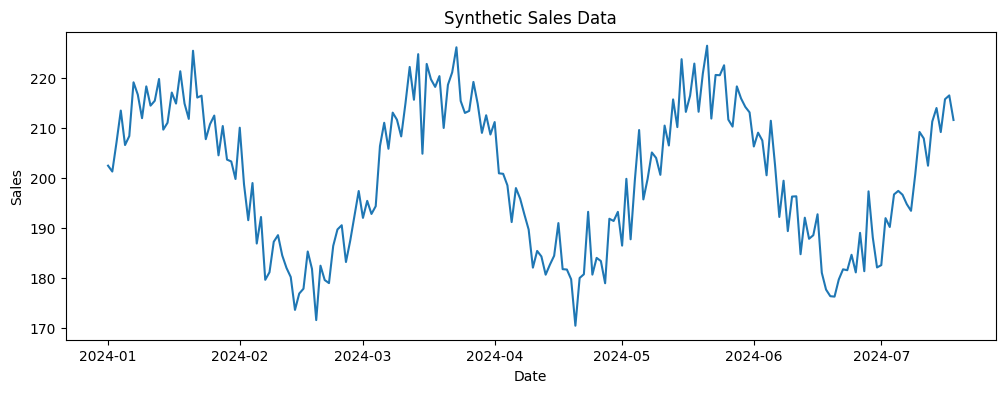

In [3]:

plt.figure(figsize=(12,4))
plt.plot(df["date"], df["sales"])
plt.title("Synthetic Sales Data")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()



# 5 Data Validation (Quality Gate)

Production systems validate incoming data before processing.


In [4]:

def validate_data(df):

    if df.isnull().sum().sum() > 0:
        raise ValueError("Missing values detected")

    if (df["sales"] < 0).any():
        raise ValueError("Negative sales detected")

    print("Data validation passed")
    return df


df = validate_data(df)


Data validation passed



# 6 Feature Engineering Pipeline

Raw data is transformed into forecasting features.


In [5]:

def create_features(df):

    df = df.copy()

    df["lag_1"] = df["sales"].shift(1)
    df["rolling_mean_7"] = df["sales"].rolling(7).mean()
    df["day_of_week"] = pd.to_datetime(df["date"]).dt.dayofweek

    df = df.dropna()

    return df


feature_df = create_features(df)

feature_df.head()


,date,sales,lag_1,rolling_mean_7,day_of_week
6,2024-01-07,219.188914,208.417826,208.392949,6
7,2024-01-08,216.721527,219.188914,210.426942,0
8,2024-01-09,211.999750,216.721527,211.954714,1
9,2024-01-10,218.379338,211.999750,213.550073,2
10,2024-01-11,214.512331,218.379338,213.691041,3



# 7 Model Training

We train an XGBoost forecasting model.


In [6]:

features = ["lag_1", "rolling_mean_7", "day_of_week"]

X = feature_df[features]
y = feature_df["sales"]

model = XGBRegressor()

model.fit(X, y)

print("Model training completed")


Model training completed



# 8 Forecast Generation

The trained model generates predictions.


In [7]:

predictions = model.predict(X)

feature_df["forecast"] = predictions

feature_df[["date", "sales", "forecast"]].head()


,date,sales,forecast
6,2024-01-07,219.188914,219.098846
7,2024-01-08,216.721527,216.703293
8,2024-01-09,211.999750,212.039581
9,2024-01-10,218.379338,218.275375
10,2024-01-11,214.512331,214.521698



# 9 Monitoring & Evaluation

Production systems continuously monitor forecasting quality.


In [8]:

mae = mean_absolute_error(
    feature_df["sales"],
    feature_df["forecast"]
)

rmse = np.sqrt(
    mean_squared_error(
        feature_df["sales"],
        feature_df["forecast"]
    )
)

print("MAE:", round(mae, 3))
print("RMSE:", round(rmse, 3))


MAE: 0.044
RMSE: 0.061



# 10 Simulating Drift

We artificially introduce demand drift after timestep 100.


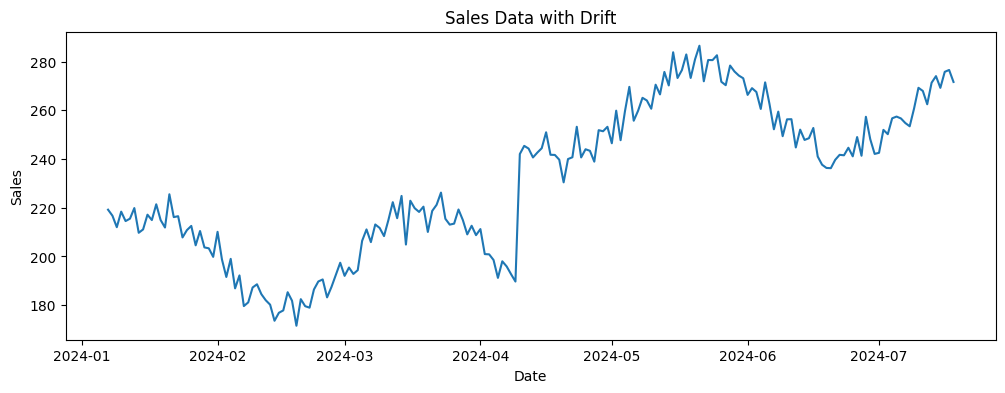

In [9]:

drift_df = feature_df.copy()

drift_df.loc[100:, "sales"] += 60

plt.figure(figsize=(12,4))
plt.plot(drift_df["date"], drift_df["sales"])
plt.title("Sales Data with Drift")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()



# 11 Drift Detection

The system evaluates whether model performance has degraded.


In [10]:

drift_predictions = model.predict(
    drift_df[features]
)

drift_mae = mean_absolute_error(
    drift_df["sales"],
    drift_predictions
)

print("Original MAE:", round(mae, 3))
print("MAE After Drift:", round(drift_mae, 3))

if drift_mae > mae * 2:
    print("Drift detected")
else:
    print("No significant drift")


Original MAE: 0.044
MAE After Drift: 30.95
Drift detected



# 12 Automatic Retraining Logic

If performance drops significantly, retraining is triggered automatically.


In [11]:

threshold = mae * 2

if drift_mae > threshold:

    print("Retraining triggered")

    X_new = drift_df[features]
    y_new = drift_df["sales"]

    retrained_model = XGBRegressor()

    retrained_model.fit(X_new, y_new)

    new_preds = retrained_model.predict(X_new)

    new_mae = mean_absolute_error(y_new, new_preds)

    print("New MAE after retraining:", round(new_mae, 3))


Retraining triggered
New MAE after retraining: 0.445



# 13 Backtesting (Rolling Window Evaluation)

Backtesting evaluates stability over time.


In [12]:

data = drift_df["sales"].values

window = 50
errors = []

for i in range(window, len(data)-10):

    train = data[i-window:i]
    test = data[i:i+10]

    X_train = np.arange(len(train)).reshape(-1,1)
    y_train = train

    X_test = np.arange(len(train), len(train)+10).reshape(-1,1)

    model_bt = RandomForestRegressor()

    model_bt.fit(X_train, y_train)

    preds = model_bt.predict(X_test)

    error = mean_absolute_error(test, preds)

    errors.append(error)

print("Average Backtest Error:", round(np.mean(errors), 3))


Average Backtest Error: 10.212



# 14 A/B Testing

A/B testing compares models in live production conditions.


In [13]:

actual = np.random.rand(100)

model_a_preds = actual + np.random.normal(0, 0.1, 100)
model_b_preds = actual + np.random.normal(0, 0.08, 100)

error_a = mean_absolute_error(actual, model_a_preds)
error_b = mean_absolute_error(actual, model_b_preds)

print("Model A Error:", round(error_a, 3))
print("Model B Error:", round(error_b, 3))

if error_b < error_a:
    print("Model B performs better")
else:
    print("Model A performs better")


Model A Error: 0.079
Model B Error: 0.058
Model B performs better



# 15 Deployment Concepts

Production systems may use:
- Batch forecasting
- Real-time forecasting APIs
- Blue/Green deployment
- Shadow deployment
- Rollback strategies



# 16 MLOps Orchestration Concept

Workflow orchestration tools such as Airflow automate execution dependencies.


In [14]:

pipeline_steps = [
    "Load Data",
    "Validate Data",
    "Generate Features",
    "Train Model",
    "Generate Forecasts",
    "Monitor Performance",
    "Trigger Retraining"
]

for step in pipeline_steps:
    print("Executing:", step)


Executing: Load Data
Executing: Validate Data
Executing: Generate Features
Executing: Train Model
Executing: Generate Forecasts
Executing: Monitor Performance
Executing: Trigger Retraining



# 17 Logging MAE Over Time

Monitoring systems store forecasting errors continuously.


In [15]:

mae_log = pd.DataFrame({
    "timestamp": pd.date_range(
        start="2024-01-01",
        periods=len(errors)
    ),
    "mae": errors
})

mae_log.head()


,timestamp,mae
0,2024-01-01,7.544551
1,2024-01-02,12.572883
2,2024-01-03,13.040031
3,2024-01-04,11.752383
4,2024-01-05,9.437052


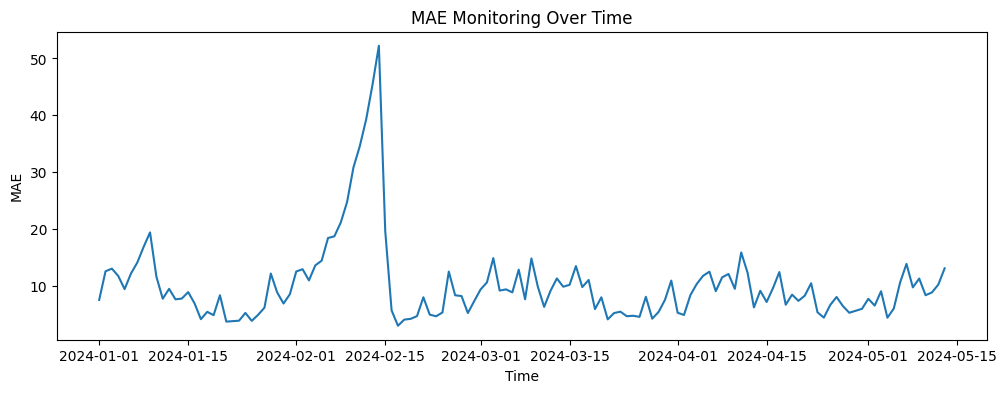

In [16]:

plt.figure(figsize=(12,4))
plt.plot(mae_log["timestamp"], mae_log["mae"])
plt.title("MAE Monitoring Over Time")
plt.xlabel("Time")
plt.ylabel("MAE")
plt.show()



# 18 Failure Modes in Production

Common forecasting failures include:
- Data pipeline failures
- Drift
- Feature mismatches
- Missing predictions
- Silent degradation
- API latency spikes



# 19 Summary

This notebook demonstrated:

- Forecasting as a continuous production system
- Monitoring and drift detection
- Automatic retraining
- Backtesting and A/B testing
- MLOps automation concepts
- Production reliability thinking

The key idea is that forecasting systems are living systems that continuously adapt to changing environments.
